In [1]:
# --- 1. 导入所有必要的依赖包 ---
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader  # 补上了 DataLoader
from sklearn.model_selection import train_test_split

# --- 2. 定义标签映射 ---
LABEL_MAP = {
    "Normal": 0,
    "IR_007": 1, "IR_014": 2, "IR_021": 3,
    "B_007": 4,  "B_014": 5,  "B_021": 6,
    "OR_007": 7, "OR_014": 8, "OR_021": 9
}

# --- 3. 定义数据集类 ---
class GAFDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # 读取图像
        img = np.load(self.file_paths[idx])
        # PyTorch 要求输入通道在前: (C, H, W)
        img = img.reshape(1, 128, 128).astype(np.float32)
        label = self.labels[idx]
        return torch.tensor(img), torch.tensor(label, dtype=torch.long)

# --- 4. 定义数据加载函数 ---
def load_data(channel="DE", test_size=0.2, val_size=0.1):
    base_dir = f"./CWRU_GAF128/{channel}"
    all_files = []
    all_labels = []
    
    # 遍历所有类别文件夹
    for label_str, label_idx in LABEL_MAP.items():
        folder_path = os.path.join(base_dir, label_str)
        files = glob.glob(os.path.join(folder_path, "*.npy"))
        all_files.extend(files)
        all_labels.extend([label_idx] * len(files))
        
    # 划分训练集和临时测试集 (包含验证集)
    X_train, X_temp, y_train, y_temp = train_test_split(
        all_files, all_labels, test_size=(test_size + val_size), random_state=42, stratify=all_labels
    )
    # 划分验证集和最终测试集 (用于后续 D-S 融合)
    ratio = test_size / (test_size + val_size)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=ratio, random_state=42, stratify=y_temp
    )
    
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

In [2]:
import matplotlib.pyplot as plt

# 1. 曲线平滑函数
def smooth_curve(points, factor=0.8):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

# 2. 训练曲线绘制与保存函数
def plot_training_curve(history, channel_name="DE"):
    epochs = range(1, len(history['loss']) + 1)
    smoothed_loss = smooth_curve(history['loss'], factor=0.8)
    smoothed_acc = smooth_curve(history['val_acc'], factor=0.8)
    
    plt.figure(figsize=(12, 5))
    
    # 绘制 Loss 曲线
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['loss'], color='lightblue', alpha=0.6, label='Raw Loss')
    plt.plot(epochs, smoothed_loss, color='blue', linewidth=2, label='Smoothed Loss')
    plt.title(f'{channel_name} - Training Loss', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    
    # 绘制 Accuracy 曲线
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_acc'], color='lightcoral', alpha=0.6, label='Raw Acc')
    plt.plot(epochs, smoothed_acc, color='red', linewidth=2, label='Smoothed Acc')
    plt.title(f'{channel_name} - Validation Acc', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.ylim(0, 105) 
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    
    plt.tight_layout()
    # 动态保存图片名称，防止被覆盖
    save_path = f'training_curve_{channel_name}.png'
    plt.savefig(save_path, dpi=300)
    print(f"\n带平滑效果的训练曲线已保存为: {save_path}")
    plt.show()

# 1、2d-cnn（无morlet+se）

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Base_CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(Base_CNN, self).__init__()
        
        # --- 前端特征提取层 (替换原有 MSMorlet 结构) ---
        # 使用单路标准卷积，卷积核大小取中间值 15x15
        # 输出通道设为 24，以保持与原模型拼接后的通道数一致
        self.front_conv = nn.Sequential(
            nn.Conv2d(1, 24, kernel_size=15, padding=7),
            nn.BatchNorm2d(24),
            nn.ReLU(inplace=True)
        )
        
        # --- 注意力层 ---
        # 方案 1 移除了 SEBlock
        
        # --- 后端主干网络 (与原代码 conv_block 保持一致) ---
        self.conv_block = nn.Sequential(
            # 第一层卷积
            nn.Conv2d(24, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 128x128 -> 64x64
            
            # 第二层卷积
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 64x64 -> 32x32
            
            # 第三层卷积
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.2),  # 2D Dropout 抑制过拟合
            nn.AdaptiveAvgPool2d((1, 1)) 
        )
        
        # --- 分类层 ---
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # 1. 前端标准卷积提取特征
        x_features = self.front_conv(x) # 输出形状: [batch, 24, 128, 128]
        
        # 2. 进入骨干网络 (跳过了 SEBlock)
        x_conv = self.conv_block(x_features) # 输出形状: [batch, 128, 1, 1]
        
        # 3. 展平与分类
        x_flat = x_conv.view(x_conv.size(0), -1) 
        out = self.fc(x_flat)
        return out

方案 1 模型输出形状: torch.Size([1, 10])


In [4]:
def train_model_base(channel_name="DE", num_epochs=150, batch_size=32):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"正在使用 {device} 训练 {channel_name} 支路模型 (方案1: Base-CNN)...")
    
    # 加载数据 (假设 load_data 和 GAFDataset 已在外部定义)
    train_data, val_data, test_data = load_data(channel=channel_name)
    train_loader = DataLoader(GAFDataset(*train_data), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(GAFDataset(*val_data), batch_size=batch_size, shuffle=False)
    
    print(f"训练集样本数: {len(train_loader.dataset)}, 验证集样本数: {len(val_loader.dataset)}")
    
    # 1. 实例化方案 1 的模型
    model = Base_CNN(num_classes=10).to(device)
    
    # 标签平滑防过拟合
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
                  
    # 2. 修改优化器配置：Base_CNN 没有单独的 Morlet 层，直接对全局使用 3e-4 的学习率
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)
    
    # 余弦退火学习率调度器
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, 
        T_max=num_epochs, 
        eta_min=1e-6
    )
    
    best_acc = 0.0
    history = {'loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        # 验证集评估
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        epoch_loss = running_loss / len(train_loader)
        val_acc = 100 * correct / total
        
        history['loss'].append(epoch_loss)
        history['val_acc'].append(val_acc)
        
        # 3. 修改打印逻辑：现在只有一个统一的学习率
        current_lr = optimizer.param_groups[0]['lr']
        
        
        # 重点：CosineAnnealingLR 的 step 必须放在 Epoch 循环的末尾！
        scheduler.step()
        
        if val_acc > best_acc:
            best_acc = val_acc
            # 修改保存的文件名，加上 Base_CNN 标识，防止覆盖其他方案的权重
            torch.save(model.state_dict(), f"best_model_Base_CNN_{channel_name}.pth")
            
    print(f"\n{channel_name} 支路 (Base-CNN) 训练完成！最佳验证集准确率: {best_acc:.2f}%")
    
    # 您可以稍微修改 plot_training_curve 里面的标题或保存路径以区分不同实验
    plot_training_curve(history, channel_name=f"{channel_name}_Base_CNN")
    
    return history

正在使用 cuda 训练 DE 支路模型 (方案1: Base-CNN)...
训练集样本数: 1490, 验证集样本数: 213
Epoch [001/150], Loss: 1.9675, Val Acc: 23.94%, LR: 0.000300
Epoch [002/150], Loss: 1.5874, Val Acc: 24.41%, LR: 0.000300
Epoch [003/150], Loss: 1.3967, Val Acc: 21.60%, LR: 0.000300
Epoch [004/150], Loss: 1.2682, Val Acc: 33.33%, LR: 0.000300
Epoch [005/150], Loss: 1.1936, Val Acc: 11.27%, LR: 0.000299
Epoch [006/150], Loss: 1.1612, Val Acc: 15.49%, LR: 0.000299
Epoch [007/150], Loss: 1.0894, Val Acc: 29.58%, LR: 0.000299
Epoch [008/150], Loss: 1.0604, Val Acc: 28.17%, LR: 0.000298
Epoch [009/150], Loss: 1.0266, Val Acc: 11.27%, LR: 0.000298
Epoch [010/150], Loss: 0.9890, Val Acc: 41.78%, LR: 0.000297
Epoch [011/150], Loss: 0.9625, Val Acc: 23.47%, LR: 0.000297
Epoch [012/150], Loss: 0.9545, Val Acc: 24.41%, LR: 0.000296
Epoch [013/150], Loss: 0.9274, Val Acc: 21.13%, LR: 0.000295
Epoch [014/150], Loss: 0.9378, Val Acc: 18.31%, LR: 0.000294
Epoch [015/150], Loss: 0.9154, Val Acc: 23.00%, LR: 0.000294
Epoch [016/150], Lo

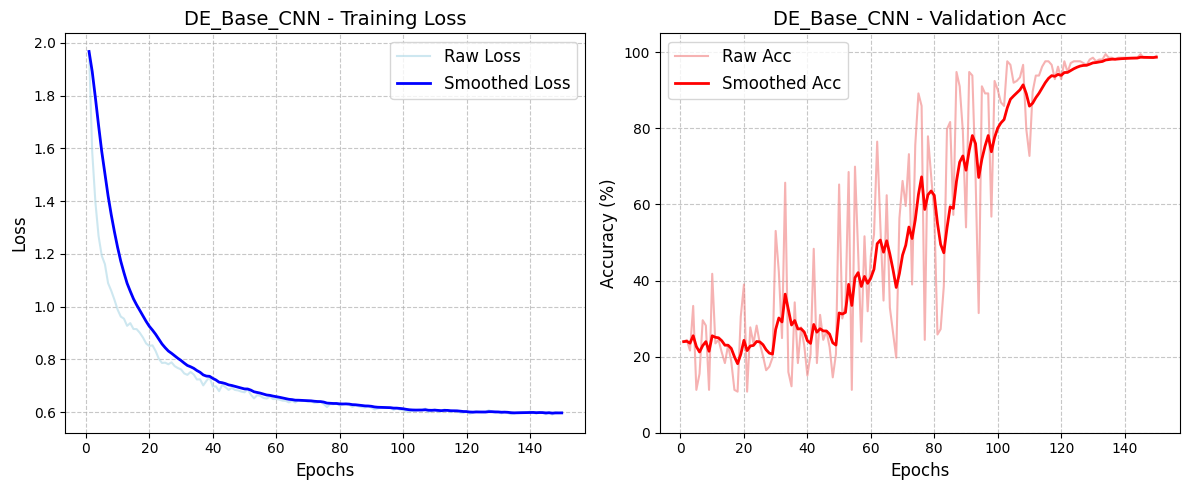

正在使用 cuda 训练 FE 支路模型 (方案1: Base-CNN)...
训练集样本数: 1481, 验证集样本数: 212
Epoch [001/150], Loss: 2.0810, Val Acc: 10.85%, LR: 0.000300
Epoch [002/150], Loss: 1.7815, Val Acc: 10.85%, LR: 0.000300
Epoch [003/150], Loss: 1.5386, Val Acc: 10.85%, LR: 0.000300
Epoch [004/150], Loss: 1.3482, Val Acc: 11.79%, LR: 0.000300
Epoch [005/150], Loss: 1.2483, Val Acc: 32.55%, LR: 0.000299
Epoch [006/150], Loss: 1.1656, Val Acc: 21.23%, LR: 0.000299
Epoch [007/150], Loss: 1.0844, Val Acc: 14.15%, LR: 0.000299
Epoch [008/150], Loss: 1.0508, Val Acc: 25.47%, LR: 0.000298
Epoch [009/150], Loss: 1.0025, Val Acc: 22.17%, LR: 0.000298
Epoch [010/150], Loss: 0.9730, Val Acc: 59.91%, LR: 0.000297
Epoch [011/150], Loss: 0.9705, Val Acc: 39.15%, LR: 0.000297
Epoch [012/150], Loss: 0.9302, Val Acc: 10.85%, LR: 0.000296
Epoch [013/150], Loss: 0.9203, Val Acc: 41.51%, LR: 0.000295
Epoch [014/150], Loss: 0.8851, Val Acc: 12.26%, LR: 0.000294
Epoch [015/150], Loss: 0.8704, Val Acc: 37.74%, LR: 0.000294
Epoch [016/150], Lo

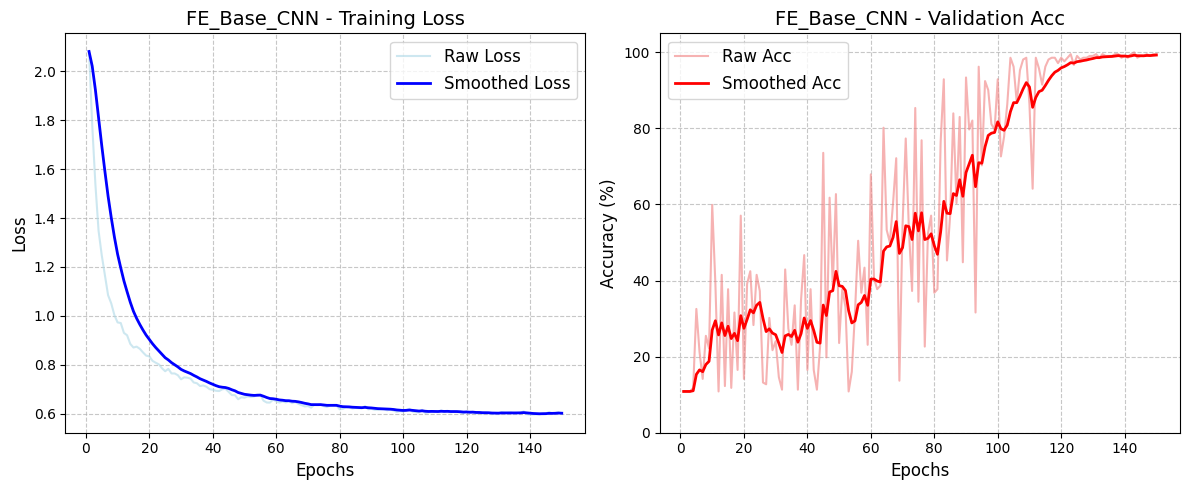

In [5]:

# ==========================================
# 1. 训练 驱动端 (DE) 支路
# ==========================================
history_DE_base = train_model_base(channel_name="DE", num_epochs=150)

# ==========================================
# 2. 训练 风扇端 (FE) 支路
# ==========================================
history_FE_base = train_model_base(channel_name="FE", num_epochs=150)

# 方案2、w-cnn

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class W_CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(W_CNN, self).__init__()
        
        # --- 前端特征提取层 (单尺度 Morlet 小波卷积) ---
        # 仅保留中间尺度 15x15，为了与后续网络对接，输出通道数直接设为 24
        self.ms = MorletConv2d(out_channels=24, kernel_size=15)
        self.bn_morlet = nn.BatchNorm2d(24)
        
        # --- 注意力层 ---
        # 方案 2 移除 SEBlock
        
        # --- 后端主干网络 (与 Base-CNN 保持完全一致) ---
        self.conv_block = nn.Sequential(
            nn.Conv2d(24, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 128x128 -> 64x64
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 64x64 -> 32x32
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.2),  
            nn.AdaptiveAvgPool2d((1, 1)) 
        )
        
        # --- 分类层 ---
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # 1. 单尺度 Morlet 提取特征
        x_features = self.ms(x)
        x_features = self.bn_morlet(x_features)
        
        # 2. 直接进入骨干网络 (跳过 SEBlock)
        x_conv = self.conv_block(x_features)
        
        # 3. 展平与分类
        x_flat = x_conv.view(x_conv.size(0), -1) 
        out = self.fc(x_flat)
        return out

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class MorletConv2d(nn.Module):
    def __init__(self, out_channels, kernel_size):
        super(MorletConv2d, self).__init__()
        self.kernel_size = kernel_size
        self.out_channels = out_channels
        
        # 可学习参数：中心频率 f 和 尺度 sigma
        self.f = nn.Parameter(torch.rand(out_channels, 1, 1) * 2) 
        self.sigma = nn.Parameter(torch.rand(out_channels, 1, 1) + 1.0)
        
        # 预设空间坐标网格
        grid = np.linspace(-1, 1, kernel_size)
        x, y = np.meshgrid(grid, grid)
        self.register_buffer('grid_r', torch.FloatTensor(np.sqrt(x**2 + y**2)))

    def forward(self, x):
        # 1. 计算高斯窗
        gaussian_window = torch.exp(-(self.grid_r**2) / (2 * (self.sigma**2) + 1e-6))
        
        # 2. 生成复数小波：实部 (cos) 和 虚部 (sin)
        kernel_real = gaussian_window * torch.cos(2 * np.pi * self.f * self.grid_r)
        kernel_imag = gaussian_window * torch.sin(2 * np.pi * self.f * self.grid_r)
        
        # 扩展维度以适配 F.conv2d
        kernel_real = kernel_real.unsqueeze(1)
        kernel_imag = kernel_imag.unsqueeze(1)
        
        # 3. 分别进行实部和虚部卷积
        out_real = F.conv2d(x, kernel_real, padding=self.kernel_size//2)
        out_imag = F.conv2d(x, kernel_imag, padding=self.kernel_size//2)
        
        # 4. 特征融合：计算模长（提取包络特征）
        out = torch.sqrt(out_real**2 + out_imag**2 + 1e-6)
        
        return out

In [8]:
import torch.optim as optim

def train_model_w_cnn(channel_name="DE", num_epochs=150, batch_size=32):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"正在使用 {device} 训练 {channel_name} 支路模型 (方案2: W-CNN)...")
    
    train_data, val_data, test_data = load_data(channel=channel_name)
    train_loader = DataLoader(GAFDataset(*train_data), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(GAFDataset(*val_data), batch_size=batch_size, shuffle=False)
    
    # 1. 实例化方案 2 模型
    model = W_CNN(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    # 2. 恢复参数分组：分离 Morlet 层参数和普通卷积层参数
    morlet_params = list(model.ms.parameters())
    base_params = list(model.bn_morlet.parameters()) + \
                  list(model.conv_block.parameters()) + \
                  list(model.fc.parameters())
                  
    # 使用与原模型一致的学习率配置
    optimizer = optim.AdamW([
        {'params': morlet_params, 'lr': 1e-4}, 
        {'params': base_params, 'lr': 3e-4}
    ], weight_decay=1e-3)
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-6
    )
    
    best_acc = 0.0
    history = {'loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        epoch_loss = running_loss / len(train_loader)
        val_acc = 100 * correct / total
        
        history['loss'].append(epoch_loss)
        history['val_acc'].append(val_acc)
        
        # 恢复双学习率打印
        lr_morlet = optimizer.param_groups[0]['lr']
        lr_base = optimizer.param_groups[1]['lr']
       
        
        scheduler.step()
        
        if val_acc > best_acc:
            best_acc = val_acc
            # 保存方案 2 的专属模型文件
            torch.save(model.state_dict(), f"best_model_W_CNN_{channel_name}.pth")
            
    print(f"\n{channel_name} 支路 (W-CNN) 训练完成！最佳验证集准确率: {best_acc:.2f}%")
    plot_training_curve(history, channel_name=f"{channel_name}_W_CNN")
    
    return history

正在使用 cuda 训练 DE 支路模型 (方案2: W-CNN)...
Epoch [001/150], Loss: 1.9171, Val Acc: 32.39%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [002/150], Loss: 1.6704, Val Acc: 45.07%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [003/150], Loss: 1.5116, Val Acc: 72.77%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [004/150], Loss: 1.4019, Val Acc: 41.31%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [005/150], Loss: 1.3143, Val Acc: 74.65%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [006/150], Loss: 1.2809, Val Acc: 60.09%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [007/150], Loss: 1.2450, Val Acc: 72.30%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [008/150], Loss: 1.1898, Val Acc: 69.48%, LR(Morlet): 0.000099, LR(Base): 0.000298
Epoch [009/150], Loss: 1.1799, Val Acc: 71.83%, LR(Morlet): 0.000099, LR(Base): 0.000298
Epoch [010/150], Loss: 1.1347, Val Acc: 82.63%, LR(Morlet): 0.000099, LR(Base): 0.000297
Epoch [011/150], Loss: 1.1348, Val Acc: 57.28%, LR(Morlet): 0.000099, LR(

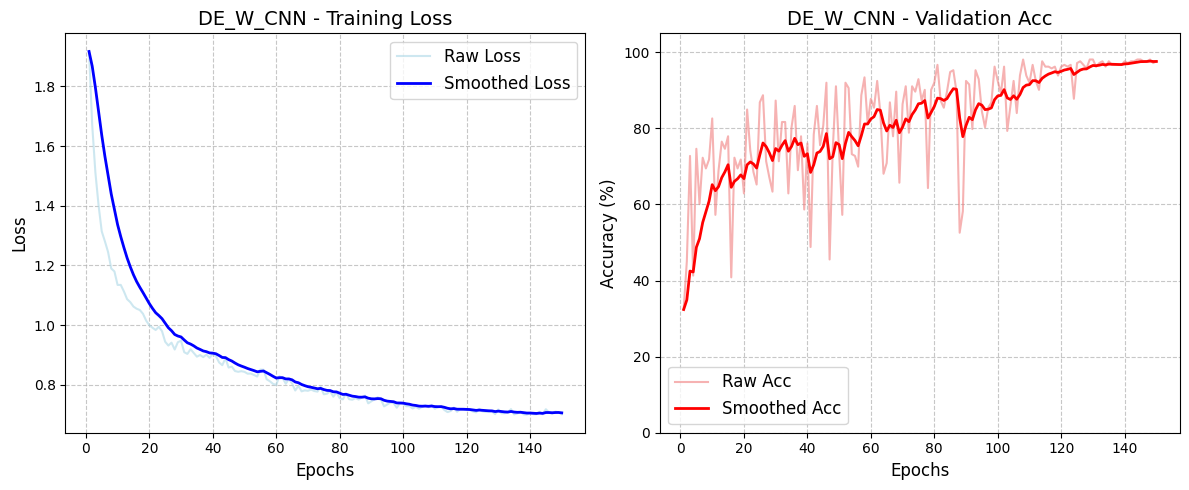

正在使用 cuda 训练 FE 支路模型 (方案2: W-CNN)...
Epoch [001/150], Loss: 2.0807, Val Acc: 23.11%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [002/150], Loss: 1.8743, Val Acc: 40.09%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [003/150], Loss: 1.7398, Val Acc: 47.17%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [004/150], Loss: 1.6321, Val Acc: 56.60%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [005/150], Loss: 1.5617, Val Acc: 67.92%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [006/150], Loss: 1.4706, Val Acc: 60.38%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [007/150], Loss: 1.4053, Val Acc: 62.26%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [008/150], Loss: 1.3404, Val Acc: 58.49%, LR(Morlet): 0.000099, LR(Base): 0.000298
Epoch [009/150], Loss: 1.2778, Val Acc: 73.58%, LR(Morlet): 0.000099, LR(Base): 0.000298
Epoch [010/150], Loss: 1.2285, Val Acc: 61.79%, LR(Morlet): 0.000099, LR(Base): 0.000297
Epoch [011/150], Loss: 1.1827, Val Acc: 74.53%, LR(Morlet): 0.000099, LR(

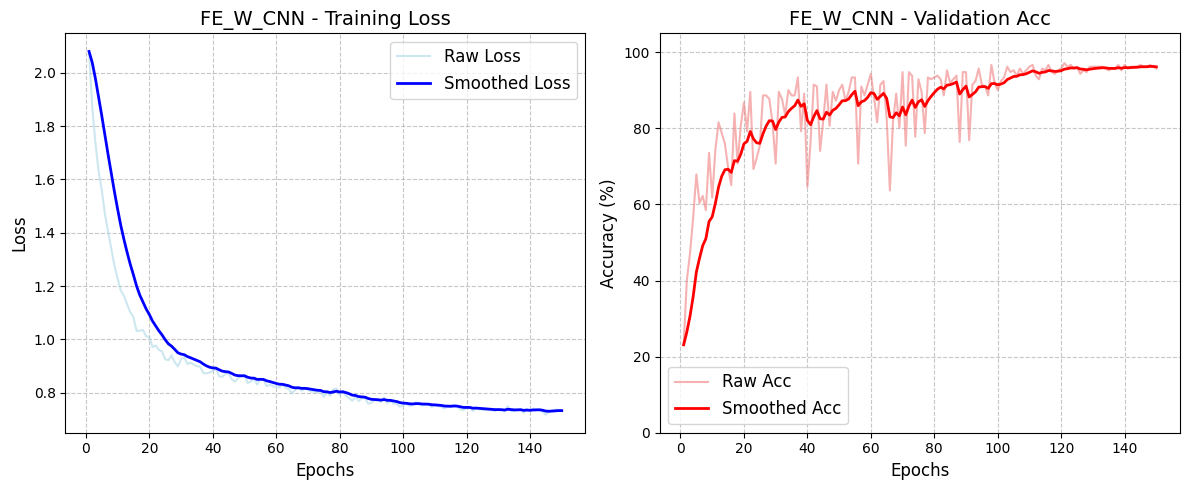

{'loss': [2.080742194297466,
  1.8742774344505149,
  1.739840142270352,
  1.6321398324154792,
  1.5616571116954723,
  1.4705587295775717,
  1.4053249663495002,
  1.3404432763444616,
  1.2777762514479616,
  1.2285185773321923,
  1.1827389585210921,
  1.1635052117895572,
  1.1309150825155543,
  1.1017426556729255,
  1.0822692437374846,
  1.0305390776471888,
  1.0323482802573671,
  1.034885253043885,
  1.0109640474015094,
  1.009172539761726,
  0.970686953118507,
  0.9765673913854234,
  0.9596511670883666,
  0.9546667489599674,
  0.9253864820967329,
  0.9213136561373447,
  0.9396701201479486,
  0.9137244909367663,
  0.8982067590064191,
  0.9241092648911984,
  0.9333040676218398,
  0.9069136901104704,
  0.9119640474623822,
  0.9050381259715303,
  0.8992613211591193,
  0.8973132917221557,
  0.873487521993353,
  0.8718224966779669,
  0.8749984071609822,
  0.8811470549157325,
  0.8887946529591337,
  0.8613235024695701,
  0.8587215124292576,
  0.871066135294894,
  0.8722193456710653,
  0.84951

In [9]:
train_model_w_cnn(channel_name="DE", num_epochs=150)
train_model_w_cnn(channel_name="FE", num_epochs=150)

# 3、多尺度小波

In [10]:
import torch
import torch.nn as nn

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

In [11]:
class MW_CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(MW_CNN, self).__init__()
        
        # --- 前端：多尺度 Morlet 小波卷积 ---
        self.ms1 = MorletConv2d(out_channels=8, kernel_size=9)
        self.ms2 = MorletConv2d(out_channels=8, kernel_size=15)
        self.ms3 = MorletConv2d(out_channels=8, kernel_size=21)
        
        self.bn_morlet = nn.BatchNorm2d(24)
        
        # --- 移除 SEBlock ---
        
        # --- 后端：骨干网络 ---
        self.conv_block = nn.Sequential(
            nn.Conv2d(24, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), 
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), 
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.2),  
            nn.AdaptiveAvgPool2d((1, 1)) 
        )
        self.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(128, num_classes))

    def forward(self, x):
        x1 = self.ms1(x)
        x2 = self.ms2(x)
        x3 = self.ms3(x)
        # 融合多尺度特征
        x_concat = torch.cat([x1, x2, x3], dim=1)
        x_features = self.bn_morlet(x_concat) 
        
        # 直接进入骨干网
        x_conv = self.conv_block(x_features)
        x_flat = x_conv.view(x_conv.size(0), -1) 
        out = self.fc(x_flat)
        return out


def train_model_mw_cnn(channel_name="DE", num_epochs=150, batch_size=32):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"正在使用 {device} 训练 {channel_name} 支路模型 (方案3: MW-CNN)...")
    
    train_data, val_data, test_data = load_data(channel=channel_name)
    train_loader = DataLoader(GAFDataset(*train_data), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(GAFDataset(*val_data), batch_size=batch_size, shuffle=False)
    
    model = MW_CNN(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    # 提取三路小波参数
    morlet_params = list(model.ms1.parameters()) + list(model.ms2.parameters()) + list(model.ms3.parameters())
    base_params = list(model.bn_morlet.parameters()) + list(model.conv_block.parameters()) + list(model.fc.parameters())
                  
    optimizer = optim.AdamW([
        {'params': morlet_params, 'lr': 1e-4}, 
        {'params': base_params, 'lr': 3e-4}
    ], weight_decay=1e-3)
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
    
    best_acc = 0.0
    history = {'loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        epoch_loss = running_loss / len(train_loader)
        val_acc = 100 * correct / total
        history['loss'].append(epoch_loss)
        history['val_acc'].append(val_acc)
        
        lr_morlet = optimizer.param_groups[0]['lr']
        lr_base = optimizer.param_groups[1]['lr']
        # print(f"Epoch [{epoch+1:03d}/{num_epochs}], Loss: {epoch_loss:.4f}, Val Acc: {val_acc:.2f}%, LR(Morlet): {lr_morlet:.6f}, LR(Base): {lr_base:.6f}")
        scheduler.step()
        
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f"best_model_MW_CNN_{channel_name}.pth")
            
    print(f"\n{channel_name} 支路 (MW-CNN) 训练完成！最佳验证集准确率: {best_acc:.2f}%")
    plot_training_curve(history, channel_name=f"{channel_name}_MW_CNN")
    return history

正在使用 cuda 训练 DE 支路模型 (方案3: MW-CNN)...
Epoch [001/150], Loss: 1.9974, Val Acc: 28.17%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [002/150], Loss: 1.6827, Val Acc: 51.64%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [003/150], Loss: 1.5663, Val Acc: 56.81%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [004/150], Loss: 1.4515, Val Acc: 72.77%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [005/150], Loss: 1.3740, Val Acc: 65.73%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [006/150], Loss: 1.2756, Val Acc: 71.36%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [007/150], Loss: 1.2127, Val Acc: 74.65%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [008/150], Loss: 1.1710, Val Acc: 75.59%, LR(Morlet): 0.000099, LR(Base): 0.000298
Epoch [009/150], Loss: 1.1427, Val Acc: 79.81%, LR(Morlet): 0.000099, LR(Base): 0.000298
Epoch [010/150], Loss: 1.0965, Val Acc: 68.54%, LR(Morlet): 0.000099, LR(Base): 0.000297
Epoch [011/150], Loss: 1.0612, Val Acc: 88.73%, LR(Morlet): 0.000099, LR

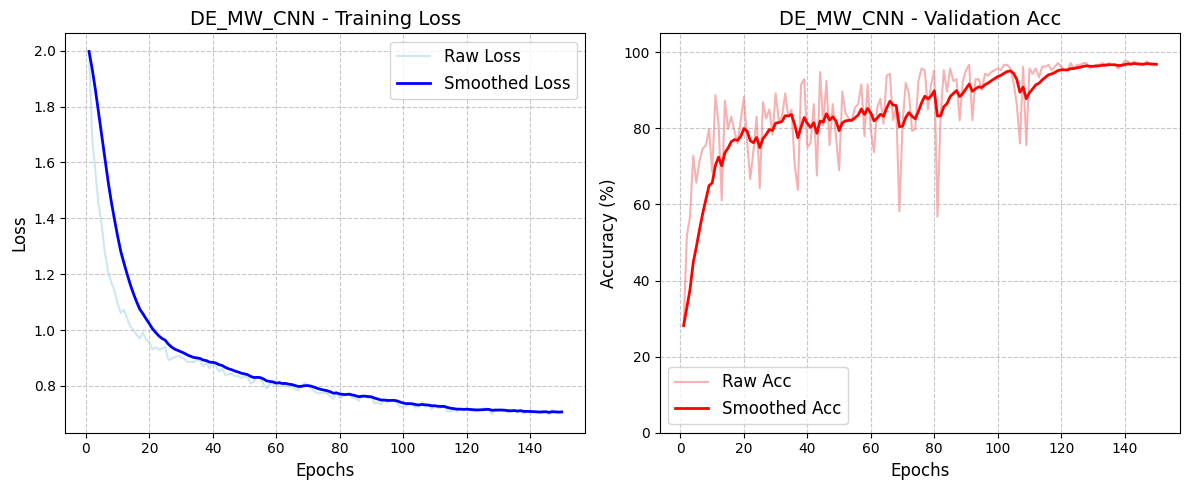

正在使用 cuda 训练 FE 支路模型 (方案3: MW-CNN)...
Epoch [001/150], Loss: 2.0702, Val Acc: 42.92%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [002/150], Loss: 1.8579, Val Acc: 56.13%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [003/150], Loss: 1.6713, Val Acc: 49.06%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [004/150], Loss: 1.5429, Val Acc: 66.51%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [005/150], Loss: 1.4488, Val Acc: 74.53%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [006/150], Loss: 1.3389, Val Acc: 75.00%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [007/150], Loss: 1.2501, Val Acc: 80.19%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [008/150], Loss: 1.1688, Val Acc: 70.28%, LR(Morlet): 0.000099, LR(Base): 0.000298
Epoch [009/150], Loss: 1.1647, Val Acc: 59.43%, LR(Morlet): 0.000099, LR(Base): 0.000298
Epoch [010/150], Loss: 1.1088, Val Acc: 70.75%, LR(Morlet): 0.000099, LR(Base): 0.000297
Epoch [011/150], Loss: 1.0909, Val Acc: 70.28%, LR(Morlet): 0.000099, LR

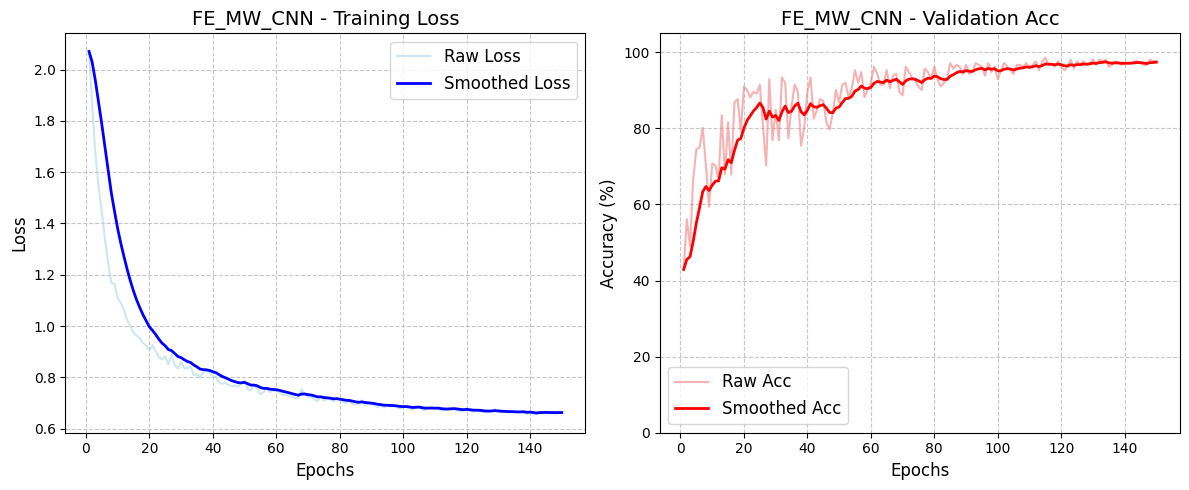

{'loss': [2.0702326906488295,
  1.8578902888805309,
  1.6713027700464775,
  1.5429052469578195,
  1.4487634187049054,
  1.338944026764403,
  1.2500950605311292,
  1.168759084762411,
  1.164683996362889,
  1.1087747254270188,
  1.0908524355989822,
  1.064394475297725,
  1.0234231466942645,
  0.9996816186194725,
  0.9743443486538339,
  0.9625948337798423,
  0.952180398271439,
  0.9338602119303764,
  0.9247132856795128,
  0.905325414018428,
  0.9263580466838593,
  0.9022763523649662,
  0.8785768950239141,
  0.87023219656437,
  0.8823929822191279,
  0.85026438439146,
  0.8875409073018014,
  0.8488925555919079,
  0.8346733552344302,
  0.8590488281655819,
  0.8368416885112194,
  0.8350516735239232,
  0.8424351430953817,
  0.8090764284133911,
  0.8125957022321985,
  0.79833082442588,
  0.8202399928519066,
  0.8271408765874011,
  0.8170272796712024,
  0.8028426487395104,
  0.8030130089597499,
  0.779727891404578,
  0.7754038863993705,
  0.778438852188435,
  0.7701775444314835,
  0.764483143674

In [12]:
train_model_mw_cnn(channel_name="DE", num_epochs=150)
train_model_mw_cnn(channel_name="FE", num_epochs=150)

# 方案4、sw-cnn

In [13]:
class SW_CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SW_CNN, self).__init__()
        
        # --- 前端：单尺度 Morlet 小波卷积 ---
        self.ms = MorletConv2d(out_channels=24, kernel_size=15)
        self.bn_morlet = nn.BatchNorm2d(24)
        
        # --- 加入 SEBlock 注意力机制 ---
        self.se = SEBlock(channels=24, reduction=4)
        
        # --- 后端：骨干网络 ---
        self.conv_block = nn.Sequential(
            nn.Conv2d(24, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), 
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), 
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.2),  
            nn.AdaptiveAvgPool2d((1, 1)) 
        )
        self.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(128, num_classes))

    def forward(self, x):
        x_features = self.ms(x)
        x_features = self.bn_morlet(x_features)
        
        # 经过 SE 层权重分配
        x_se = self.se(x_features)
        
        x_conv = self.conv_block(x_se)
        x_flat = x_conv.view(x_conv.size(0), -1) 
        out = self.fc(x_flat)
        return out


def train_model_sw_cnn(channel_name="DE", num_epochs=150, batch_size=32):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"正在使用 {device} 训练 {channel_name} 支路模型 (方案4: SW-CNN)...")
    
    train_data, val_data, test_data = load_data(channel=channel_name)
    train_loader = DataLoader(GAFDataset(*train_data), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(GAFDataset(*val_data), batch_size=batch_size, shuffle=False)
    
    model = SW_CNN(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    # 提取单路小波参数，注意这里把 SE 参数放进了 base_params
    morlet_params = list(model.ms.parameters())
    base_params = list(model.bn_morlet.parameters()) + list(model.se.parameters()) + \
                  list(model.conv_block.parameters()) + list(model.fc.parameters())
                  
    optimizer = optim.AdamW([
        {'params': morlet_params, 'lr': 1e-4}, 
        {'params': base_params, 'lr': 3e-4}
    ], weight_decay=1e-3)
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
    
    best_acc = 0.0
    history = {'loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        epoch_loss = running_loss / len(train_loader)
        val_acc = 100 * correct / total
        history['loss'].append(epoch_loss)
        history['val_acc'].append(val_acc)
        
        lr_morlet = optimizer.param_groups[0]['lr']
        lr_base = optimizer.param_groups[1]['lr']
        # print(f"Epoch [{epoch+1:03d}/{num_epochs}], Loss: {epoch_loss:.4f}, Val Acc: {val_acc:.2f}%, LR(Morlet): {lr_morlet:.6f}, LR(Base): {lr_base:.6f}")
        scheduler.step()
        
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f"best_model_SW_CNN_{channel_name}.pth")
            
    print(f"\n{channel_name} 支路 (SW-CNN) 训练完成！最佳验证集准确率: {best_acc:.2f}%")
    plot_training_curve(history, channel_name=f"{channel_name}_SW_CNN")
    return history

正在使用 cuda 训练 DE 支路模型 (方案4: SW-CNN)...
Epoch [001/150], Loss: 1.9819, Val Acc: 33.33%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [002/150], Loss: 1.6995, Val Acc: 50.70%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [003/150], Loss: 1.5950, Val Acc: 63.38%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [004/150], Loss: 1.4887, Val Acc: 61.50%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [005/150], Loss: 1.4070, Val Acc: 57.28%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [006/150], Loss: 1.3248, Val Acc: 69.01%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [007/150], Loss: 1.2933, Val Acc: 69.48%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [008/150], Loss: 1.2432, Val Acc: 71.83%, LR(Morlet): 0.000099, LR(Base): 0.000298
Epoch [009/150], Loss: 1.1998, Val Acc: 58.69%, LR(Morlet): 0.000099, LR(Base): 0.000298
Epoch [010/150], Loss: 1.2085, Val Acc: 77.46%, LR(Morlet): 0.000099, LR(Base): 0.000297
Epoch [011/150], Loss: 1.1769, Val Acc: 65.26%, LR(Morlet): 0.000099, LR

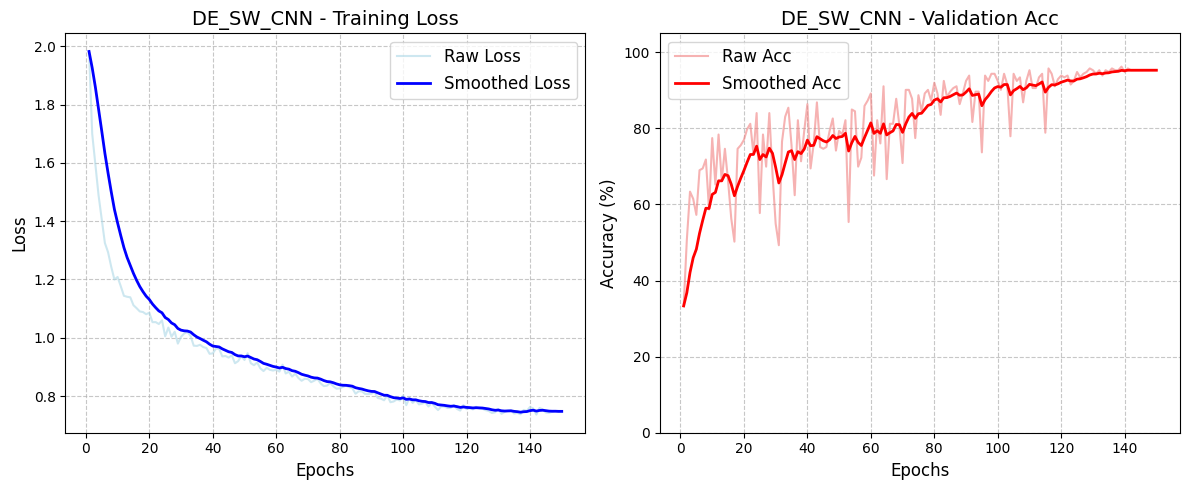

正在使用 cuda 训练 FE 支路模型 (方案4: SW-CNN)...
Epoch [001/150], Loss: 2.0789, Val Acc: 42.45%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [002/150], Loss: 1.8481, Val Acc: 37.74%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [003/150], Loss: 1.6962, Val Acc: 27.36%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [004/150], Loss: 1.5564, Val Acc: 40.09%, LR(Morlet): 0.000100, LR(Base): 0.000300
Epoch [005/150], Loss: 1.4591, Val Acc: 69.34%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [006/150], Loss: 1.3810, Val Acc: 67.92%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [007/150], Loss: 1.3078, Val Acc: 65.09%, LR(Morlet): 0.000100, LR(Base): 0.000299
Epoch [008/150], Loss: 1.2574, Val Acc: 42.45%, LR(Morlet): 0.000099, LR(Base): 0.000298
Epoch [009/150], Loss: 1.2001, Val Acc: 57.55%, LR(Morlet): 0.000099, LR(Base): 0.000298
Epoch [010/150], Loss: 1.1897, Val Acc: 70.28%, LR(Morlet): 0.000099, LR(Base): 0.000297
Epoch [011/150], Loss: 1.1493, Val Acc: 53.77%, LR(Morlet): 0.000099, LR

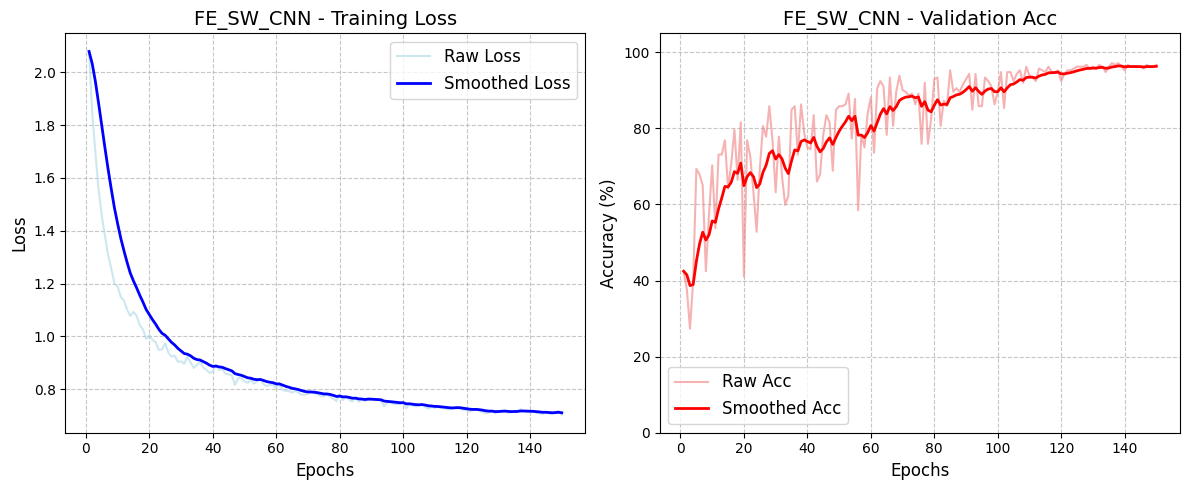

{'loss': [2.078882874326503,
  1.8480762268634552,
  1.696245754018743,
  1.556367815809047,
  1.4590716843909406,
  1.380983753407255,
  1.307841810774296,
  1.2574097044924473,
  1.2001090125834688,
  1.1896737458858084,
  1.1492566073194463,
  1.1356991415328168,
  1.101167988269887,
  1.0774024065504684,
  1.092297654202644,
  1.0780503686438216,
  1.0420874623542136,
  1.0260676906463948,
  0.9902871885198228,
  1.0045117799271928,
  0.9868703091398199,
  0.9779061586298841,
  0.9484695716107145,
  0.9503593444824219,
  0.9738449276761806,
  0.9377107632921097,
  0.9230651868150589,
  0.9271534643274673,
  0.9036055955481022,
  0.9052306286832119,
  0.8957778532454308,
  0.9220698716792655,
  0.9016770644390837,
  0.8801138959032424,
  0.8917407013000326,
  0.9035771577916247,
  0.8813380548294555,
  0.8735072866399237,
  0.861245501548686,
  0.8662080181405899,
  0.8920283634611901,
  0.8720595265956635,
  0.8763519703073704,
  0.8582726539449489,
  0.8563838867430992,
  0.852621

In [14]:
train_model_sw_cnn(channel_name="DE", num_epochs=150)
train_model_sw_cnn(channel_name="FE", num_epochs=150)